In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [75]:
plt.style.use('fivethirtyeight')
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [3]:
train_df = pd.read_csv("dataset/train_genetic_disorders.csv")
test_df  = pd.read_csv("dataset/test_genetic_disorders.csv")

In [4]:
train_df.head(5)

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,Yes,No,4.760603,Richard,NaN,Larre,...,NaN,9.857562,NaN,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,PID0x25d5,4.0,Yes,Yes,No,No,4.910669,Mike,NaN,Brycen,...,Multiple,5.522560,normal,1.0,NaN,1.0,1.0,0.0,NaN,Cystic fibrosis
2,PID0x4a82,6.0,Yes,No,No,No,4.893297,Kimberly,NaN,Nashon,...,Singular,NaN,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
3,PID0x4ac8,12.0,Yes,No,Yes,No,4.705280,Jeffery,Hoelscher,Aayaan,...,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,PID0x1bf7,11.0,Yes,No,NaN,Yes,4.720703,Johanna,Stutzman,Suave,...,Multiple,4.098210,NaN,0.0,0.0,0.0,0.0,NaN,Multifactorial genetic inheritance disorders,Cancer


In [ ]:
test_df.head(5)

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,History of anomalies in previous pregnancies,No. of previous abortion,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
0,PID0x4175,6.0,No,Yes,No,No,4.981655,Charles,NaN,Kore,...,-99,2.0,Multiple,-99.000000,slightly abnormal,True,True,True,True,True
1,PID0x21f5,10.0,Yes,No,NaN,Yes,5.118890,Catherine,NaN,Homero,...,Yes,-99.0,Multiple,8.179584,normal,False,False,False,True,False
2,PID0x49b8,5.0,No,NaN,No,No,4.876204,James,NaN,Danield,...,No,0.0,Singular,-99.000000,slightly abnormal,False,False,True,True,False
3,PID0x2d97,13.0,No,Yes,Yes,No,4.687767,Brian,NaN,Orville,...,Yes,-99.0,Singular,6.884071,normal,True,False,True,False,True
4,PID0x58da,5.0,No,NaN,NaN,Yes,5.152362,Gary,NaN,Issiah,...,No,-99.0,Multiple,6.195178,normal,True,True,True,True,False


#### Data Cleaning

In [44]:
target_col = "Genetic Disorder"
subclass_col = "Disorder Subclass"

In [45]:
drop_cols = [
    "Patient Id",
    "Patient First Name",
    "Family Name",
    "Father's name"
]

In [46]:
y = train_df[target_col].astype(str)
X = train_df.drop(columns=[target_col] + drop_cols, errors="ignore")
test_df = test_df.drop(columns=drop_cols, errors="ignore")

In [47]:
common_cols = X.columns.intersection(test_df.columns)
X = X[common_cols]
test_df = test_df[common_cols]

In [48]:
class_map = {label: idx for idx, label in enumerate(y.unique())}
y_encoded = y.map(class_map)

In [49]:
y_subclass = train_df[subclass_col].astype(str)
subclass_map = {label: idx for idx, label in enumerate(y_subclass.unique())}
y_subclass_encoded = y_subclass.map(subclass_map)

In [50]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

### Preprocessing

In [51]:
numeric_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])

In [52]:
categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

In [53]:
preprocessor = ColumnTransformer(
    [("num", numeric_pipeline, num_cols), ("cat", categorical_pipeline, cat_cols)]
)

In [54]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [55]:
y_subclass = train_df["Disorder Subclass"].astype(str)
subclass_map = {label: idx for idx, label in enumerate(y_subclass.unique())}
y_subclass_encoded = y_subclass.map(subclass_map)

In [56]:
_, _, y_sub_train, y_sub_val = train_test_split(
    X,
    y_subclass_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_subclass_encoded
)

### Models

In [78]:
def plot_feature_importance(model , top_n=20):
    
    model_fitted = model.named_steps['classifier']
    feature_names = preprocessor.get_feature_names_out()
    importances = model_fitted.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(10,6))

    plt.tight_layout()

    plt.bar(range(top_n), importances[indices][:top_n], align='center')
    plt.xticks(range(top_n), [feature_names[i] for i in indices][:top_n], rotation=90)
    plt.title(f"Top {top_n} Feature Importances")
    plt.tight_layout()
    plt.show()

In [58]:
def plot_confusion(y_true, y_pred, title):
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

In [90]:
rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                class_weight="balanced",
                random_state=42,
                min_samples_leaf=1,
                max_features="sqrt",
            ),
        ),
    ],
    memory=None,
)

In [91]:
rf_pipeline.fit(X_train, y_sub_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
rf_val_pred_classes = rf_pipeline.predict(X_val)
rf_acc = accuracy_score(y_val, rf_val_pred_classes)
rf_f1 = f1_score(y_val, rf_val_pred_classes, average="weighted")

In [62]:
print(f"Random Forest [Accuracy: {rf_acc:.4f} || F1 Score: {rf_f1:.4f}]")

Random Forest [Accuracy: 0.2488 || F1 Score: 0.1595]


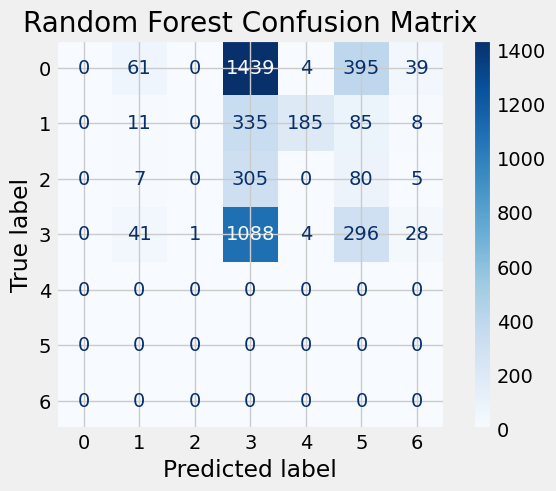

In [76]:
plot_confusion(y_val, rf_val_pred_classes, "Random Forest Confusion Matrix")

C:\Users\Sikrox\AppData\Local\Temp\ipykernel_19244\2235035443.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


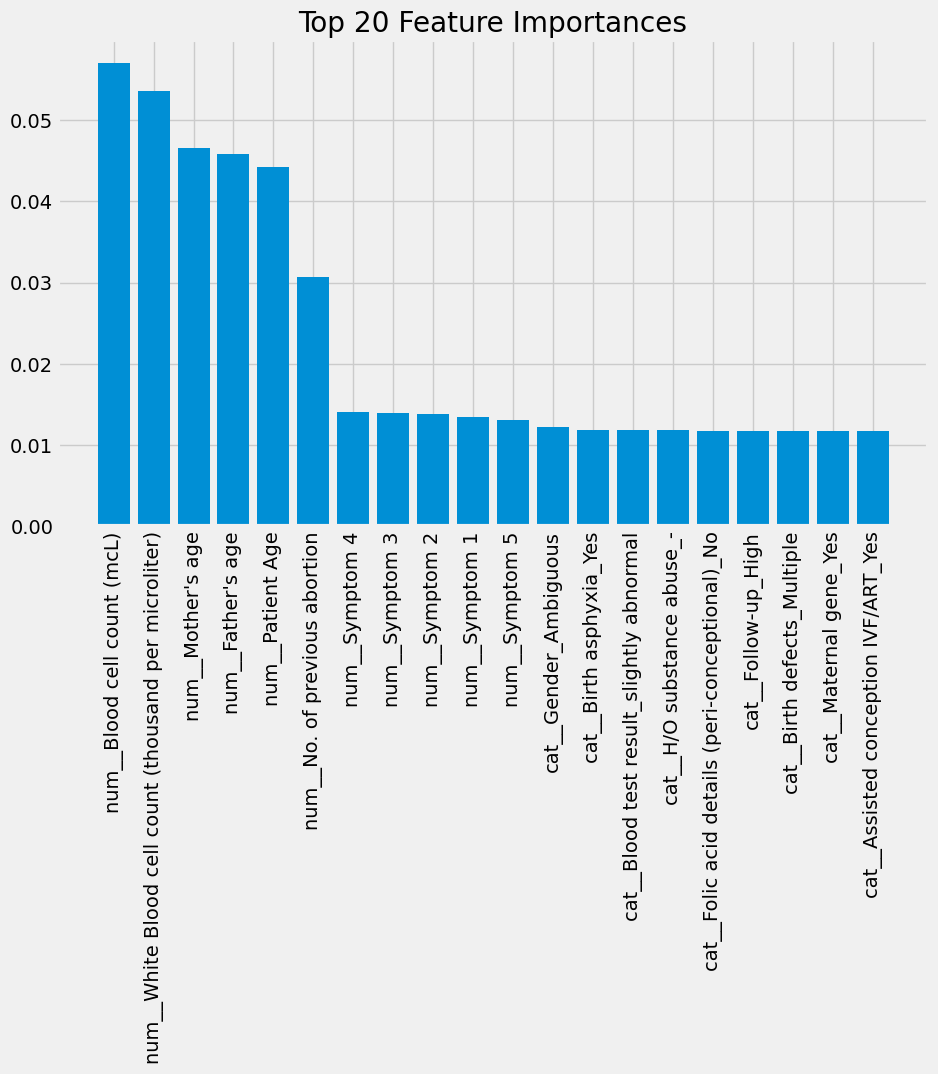

In [80]:
plot_feature_importance(rf_model, top_n=20)

In [92]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=8,         
        subsample=0.8,        
        random_state=42,
        eval_metric="mlogloss"
    ))
], memory=None)

In [93]:
xgb_pipeline.fit(X_train, y_sub_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [98]:
xgb_val_pred_classes = xgb_pipeline.predict(X_val)
xgb_acc = accuracy_score(y_val, xgb_val_pred_classes)
xgb_f1 = f1_score(y_val, xgb_val_pred_classes, average="weighted")

In [99]:
print(f"XGBoost [Accuracy: {xgb_acc:.4f} || F1 Score: {xgb_f1:.4f}]")

XGBoost [Accuracy: 0.1741 || F1 Score: 0.1362]


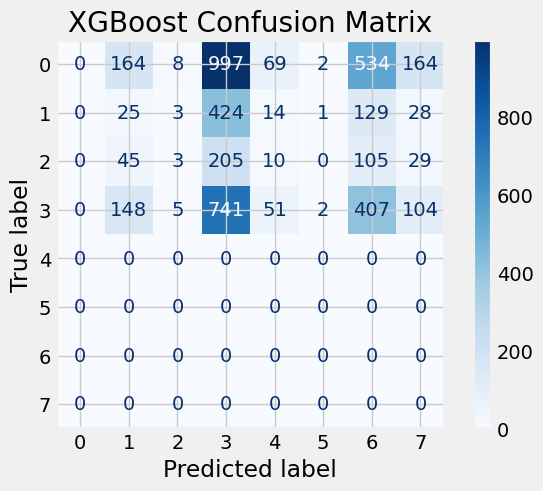

In [100]:
plot_confusion(y_val, xgb_val_pred_classes, "XGBoost Confusion Matrix")

C:\Users\Sikrox\AppData\Local\Temp\ipykernel_19244\2235035443.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


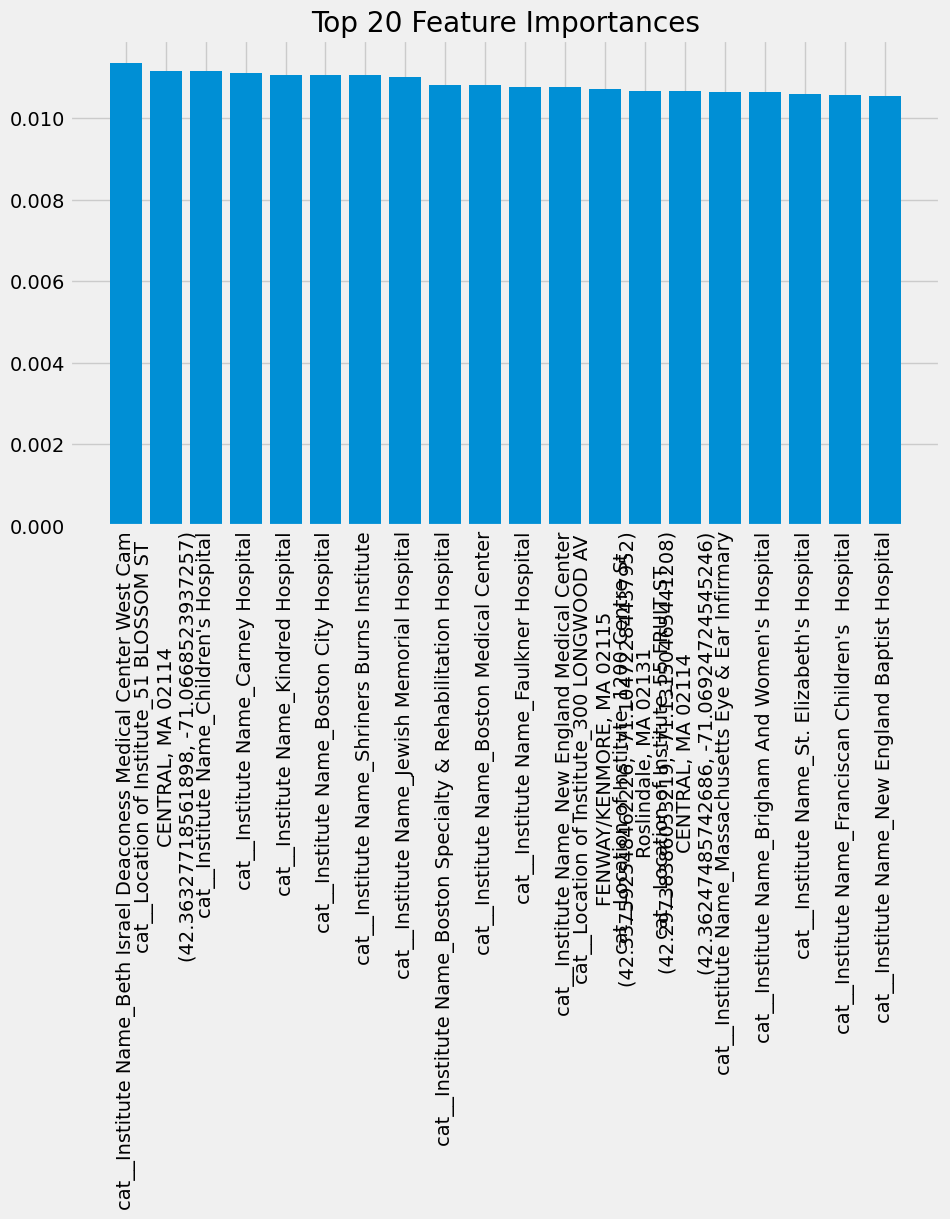

In [101]:
plot_feature_importance(xgb_model, top_n=20)

### Neural Networks

In [ ]:
rf_train_pred = rf_pipeline.predict_proba(X_train)
xgb_train_pred = xgb_pipeline.predict_proba(X_train)

In [103]:
rf_val_pred = rf_pipeline.predict_proba(X_val)
xgb_val_pred = xgb_pipeline.predict_proba(X_val)

In [104]:
stacked_train = np.hstack([rf_train_pred, xgb_train_pred])
stacked_val = np.hstack([rf_val_pred, xgb_val_pred])

In [105]:
X_train_nn = torch.tensor(stacked_train, dtype=torch.float32)
X_val_nn = torch.tensor(stacked_val, dtype=torch.float32)

y_train_nn = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_val_nn = torch.tensor(y_val.to_numpy(), dtype=torch.long)

In [106]:
class GeneticDisorderNN(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_classes=len(np.unique(y_train))):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [107]:
model = GeneticDisorderNN(input_size=X_train_nn.shape[1])

In [108]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)

In [109]:
epochs = 101

for epoch in range(epochs):

    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_nn)
    loss = criterion(outputs, y_train_nn)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_nn)
            val_loss = criterion(val_outputs, y_val_nn)
        print(f"Epoch {epoch}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")


Epoch 0, Train Loss: 1.4204, Val Loss: 1.4035
Epoch 10, Train Loss: 1.2833, Val Loss: 1.2738
Epoch 20, Train Loss: 1.2220, Val Loss: 1.2221
Epoch 30, Train Loss: 1.2155, Val Loss: 1.2155
Epoch 40, Train Loss: 1.2084, Val Loss: 1.2134
Epoch 50, Train Loss: 1.2023, Val Loss: 1.2092
Epoch 60, Train Loss: 1.1956, Val Loss: 1.2049
Epoch 70, Train Loss: 1.1879, Val Loss: 1.2014
Epoch 80, Train Loss: 1.1789, Val Loss: 1.1982
Epoch 90, Train Loss: 1.1685, Val Loss: 1.1924
Epoch 100, Train Loss: 1.1576, Val Loss: 1.1922


In [110]:
model.eval()

with torch.no_grad():
    nn_val_logits = model(X_val_nn)
    nn_val_pred_classes = torch.argmax(nn_val_logits, dim=1).numpy()

from sklearn.metrics import accuracy_score, f1_score
nn_acc = accuracy_score(y_val, nn_val_pred_classes)
nn_f1 = f1_score(y_val, nn_val_pred_classes, average="weighted")

print(f"Neural Network → Accuracy: {nn_acc:.4f}, F1 Score: {nn_f1:.4f}")

Neural Network → Accuracy: 0.4806, F1 Score: 0.3402
